# Single-molecule FRET with PIE-MFD: from photons to a distance distribution

This notebook simulates a single-molecule FRET experiment as a **photon stream**, finds
the bursts with `tttrlib`, builds the fluorescence decays out of the burst photons, and
infers the **donor-acceptor distance distribution** p(R/R0) from them, analytically.

### The experiment, for a reader who has never seen a TCSPC histogram

Molecules carrying two dyes -- a **donor** and an **acceptor** -- diffuse one at a time
through a focused laser spot. While a molecule is inside, photons arrive in a *burst* of
a millisecond or so. Two lasers alternate inside one 50 ns period:

* the **green pulse** excites the donor. The donor either emits, or hands its energy to
  the acceptor by FRET -- the closer the dyes, the more often -- and the acceptor emits
  instead. So the donor's fluorescence *lifetime* is shortened in proportion to the
  transfer, and that is what carries the distance.
* the **red pulse**, 25 ns later, excites the acceptor directly and nothing else. This is
  **PIE** (pulsed interleaved excitation). It answers a question intensity alone cannot:
  a molecule that shows no acceptor light either transfers nothing (dyes far apart) or has
  no working acceptor at all. Under the red pulse the second kind stays dark.

Four detectors record the light: green and red, each split into **parallel** and
**perpendicular** polarisation. The polarisation pair measures *anisotropy* -- how much
the dye rotated during its excited-state lifetime -- which matters here because a dye that
does not rotate freely makes the distance from FRET ambiguous.

Every photon is recorded twice over: a **macro time** (which laser pulse it came after, so
effectively *when* in the measurement, in units of the 50 ns period) and a **micro time**
(its delay after that pulse, resolved to about 30 ps). The micro times histogrammed give
the *decay*; the macro times give the bursts. `tttrlib.TTTR` is the object that holds both.

### What is inferred, and how

Eight histograms: four detectors on a **donor-only reference sample**, and four on the
**labelled sample**, each of the latter holding *both* pulses in one histogram. From them,
in one go: p(R/R0), the fraction of molecules with no acceptor, both anisotropies, the
detector calibration, the response shift, scatter and background.

The posterior is computed **analytically, with no sampler**. p(R/R0) is a spline in log p
with a roughness prior (Eilers & Marx 1996). The weight of that prior is not maximised --
that flattens the distribution -- but *integrated out*: a Laplace approximation at each node
of a grid over the weight, the nodes mixed by their evidences (INLA; Rue, Martino & Chopin,
JRSS-B 71, 319, 2009; Wood 2011).

### Where the physics comes from

Simulation and fit call **the same forward model**, the ucfret prototype
`s88_laplace_posterior`. The example therefore measures the inference, not a disagreement
between two hand-written physics implementations. What the simulation adds, and the fit
never learns, is the *experiment*: molecules drawn one at a time, Poisson burst sizes,
uncorrelated background, scattered laser light, and a burst search that decides which
photons are used at all.

> Set the environment variable `UCFRET_S88` to the directory holding
> `s88_laplace_posterior.py` if it is not at `~/dev/ucfret/investigation/pinn_pR_anisotropy`.

## 1. Everything you would want to change

This is the only cell to edit. Distances are in Angstrom, times in nanoseconds, rates in counts per second.

In [1]:
import sys, math, time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '.')            # pie_mfd.py sits beside this notebook
import pie_mfd as P

S = P.default_settings()

# -- the sample: a simple mixture of FRET molecules -------------------------
S['R0'] = 52.0                     # Foerster radius: the distance at which half the energy transfers
S['species'] = [dict(R=42.0, fraction=0.5, width=3.0, name='high FRET'),
                dict(R=62.0, fraction=0.5, width=4.0, name='low FRET')]
S['donor_only_fraction'] = 0.20    # molecules whose acceptor is missing or bleached
S['r0_donor'], S['rho_donor'] = 0.36, 1.2        # anisotropy amplitude and rotational time (ns)
S['r0_acceptor'], S['rho_acceptor'] = 0.18, 1.2

# -- the measurement --------------------------------------------------------
S['n_bursts'] = 6000               # molecules crossing the spot, labelled sample
S['n_bursts_donor'] = 2500         # the donor-only reference measurement
S['photons_per_burst'] = 110       # detected photons of an unquenched donor, green pulse
S['red_green_ratio'] = 0.55        # red-pulse photons per green-pulse photon
S['background_cps'] = 350.0        # uncorrelated background per detector
S['scatter_fraction'] = 0.02       # laser light scattered into the detectors

# -- the burst search -------------------------------------------------------
S['search_window_ms'] = 0.5        # sliding window
S['search_min_photons'] = 12       # photons it must hold to be inside a burst
S['burst_min_photons'] = 40        # photons a burst must have to be kept

# -- the analysis -----------------------------------------------------------
S['knots'] = 25                    # spline coefficients of log p(R/R0)
S['lam_nodes'] = (2.0, 1.0, 0.0, -1.0)   # log10 roughness weights the evidence mixes over
S['threads'] = 4
S['seed'] = 2026
REPEAT_SEEDS = (11, 12, 13)        # section 10: repeats of the whole experiment (set to () to skip)

t_all = time.time()

## 2. The model

The distance grid, the spline basis over it, and the interleaved time axis. The time axis is deliberately uneven: **fine right after each pulse**, where the decay changes fastest, **coarse before the next** one. A uniform 130-bin axis would put the red pulse inside a 2 ns bin and throw away its rise.

In [2]:
model = P.build_model(S)
print(f"distance grid: {len(model['rel'])} points, R/R0 from {model['rel'][0]:.2f} to {model['rel'][-1]:.2f}"
      f"  ({model['rel'][0]*S['R0']:.0f} to {model['rel'][-1]*S['R0']:.0f} A at this R0)")
print(f"time axis: {model['n_fine']} fine channels of {model['dt']*1000:.0f} ps over a {model['period']:.0f} ns period,"
      f" rebinned to {model['n_bin']} bins; red pulse at +{model['t_pie']:.1f} ns")
print(f"channels: {len(model['keys'])} physics channels for 8 measured histograms")

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
distance grid: 128 points, R/R0 from 0.40 to 2.23  (21 to 116 A at this R0)
time axis: 1563 fine channels of 32 ps over a 50 ns period, rebinned to 226 bins; red pulse at +25.0 ns
channels: 12 physics channels for 8 measured histograms


### The truth

The species table becomes a distribution on the model's own grid, and molecules are drawn from exactly that array -- so the curve plotted here is the distribution actually sampled, with no discretisation gap between the truth and what is compared against it.

mean R/R0 1.0  mean R 52.0 A


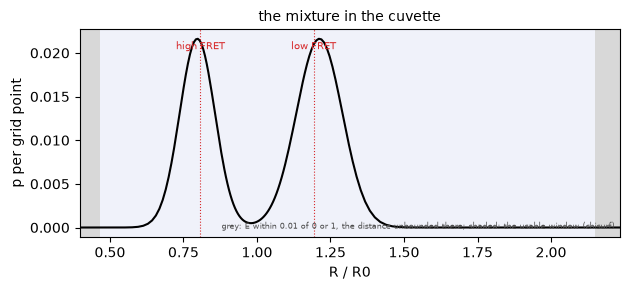

In [3]:
p_true = P.truth_distribution(model, S)
rel = model['rel']
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(rel, p_true, 'k-')
for sp in S['species']:
    ax.axvline(sp['R'] / S['R0'], color='C3', lw=0.8, ls=':')
    ax.text(sp['R'] / S['R0'], ax.get_ylim()[1] * 0.9, sp['name'], fontsize=7, ha='center', color='C3')
ax.set_xlabel('R / R0'); ax.set_ylabel('p per grid point'); ax.set_xlim(rel[0], rel[-1])
model['L'].shade_window(ax, 0.01)
ax.set_title('the mixture in the cuvette', fontsize=10); fig.tight_layout()
print('mean R/R0', round(float((p_true * rel).sum()), 4),
      ' mean R', round(float((p_true * rel).sum()) * S['R0'], 1), 'A')

## 3. One molecule's decay

The forward model is **linear in the distance distribution**: put all the weight on a
single grid point and you get that one molecule's expected decay in every detector. The
tables below hold, for each grid point, the four detectors' relative brightness and the
shape of their micro-time distribution -- including crosstalk between the colour channels,
the acceptor excited directly by the green laser, the anisotropy of both dyes, and the
detection efficiencies.

Drawing molecules from p(R/R0) and photons from these tables therefore produces exactly
the ensemble decay the fit models, plus the experiment's own noise.

  grid point   1: R/R0 0.477, green fraction 0.030


  grid point 122: R/R0 1.652, green fraction 0.840


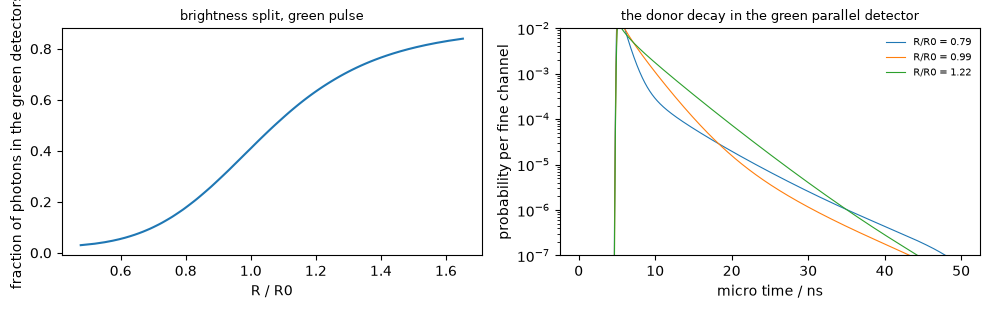

In [4]:
tab = P.physics_tables(model, S, p_true)
w = tab['w_da']; used = tab['used']
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
green = w[used, :2].sum(1) / w[used].sum(1)
ax[0].plot(rel[used], green, 'C0-'); ax[0].set_xlabel('R / R0')
ax[0].set_ylabel('fraction of photons in the green detectors')
ax[0].set_title('brightness split, green pulse', fontsize=9)
for j, c in ((used[len(used)//5], 'C0'), (used[len(used)//2], 'C1'), (used[-len(used)//5], 'C2')):
    d = np.diff(np.concatenate([[0], tab['cdf_da'][j, 0]]))
    ax[1].semilogy(np.arange(model['n_fine']) * model['dt'], np.maximum(d, 1e-9), c, lw=0.8,
                   label=f'R/R0 = {rel[j]:.2f}')
ax[1].set_xlabel('micro time / ns'); ax[1].set_ylabel('probability per fine channel')
ax[1].set_ylim(1e-7, 1e-2); ax[1].legend(fontsize=7, frameon=False)
ax[1].set_title('the donor decay in the green parallel detector', fontsize=9)
fig.tight_layout()

## 4. The photon stream

Bursts arrive at random times. Each is one molecule: either a FRET molecule at a distance
drawn from p(R/R0), or one of the acceptor-less ones. Its photon count is Poisson around a
mean proportional to that molecule's own brightness, its detector is drawn from the four
weights, and its micro time from that detector's decay. On top go scattered laser light and
a flat, uncorrelated background over the whole record.

The arrays are then handed to `tttrlib.TTTR.append_events`, which is the same object a
measurement file would give.

In [5]:
rng = np.random.default_rng(S['seed'])
stream = P.simulate_stream(model, S, p_true, tab, rng)
tttr = {s: P.to_tttr(model, d) for s, d in stream.items()}
for s, d in stream.items():
    print(f"{s}: {len(d['macro']):>8d} photons over {d['duration_s']:6.1f} s "
          f"({d['n_background']} of them background), {len(d['bursts'])} molecules")
t = tttr['DA']
print('\nas a TTTR object:', len(t.macro_times), 'events,',
      t.get_header().number_of_micro_time_channels, 'micro-time channels,',
      f"macro time resolution {t.get_header().macro_time_resolution*1e9:.0f} ns")

DA:  1317687 photons over  158.7 s (222127 of them background), 6000 molecules
D0:   377337 photons over   68.5 s (95873 of them background), 2500 molecules

as a TTTR object: 1317687 events, 1563 micro-time channels, macro time resolution 50 ns


## 5. The burst search

`tttrlib.ranges_by_time_window` slides a window over the macro times and keeps the stretches
that hold enough photons; consecutive windows that pass belong to the same molecule and are
merged, so a burst is a whole crossing rather than a window.

The scatter plot underneath is the standard PIE one. The **proximity ratio** E* is the
fraction of the green pulse's photons that came out red -- high FRET on the right. The
**stoichiometry** S is the green pulse's share of all the photons: molecules with a working
acceptor sit near one half, and molecules that stay dark under the red pulse pile up near
one. That upper band is the donor-only population, and PIE is what separates it.

DA: 5540 bursts kept of 6000 molecules, 1087284 burst photons of 1317687 (83 %)
D0: 2339 bursts kept of 2500 molecules, 281110 burst photons of 377337 (74 %)


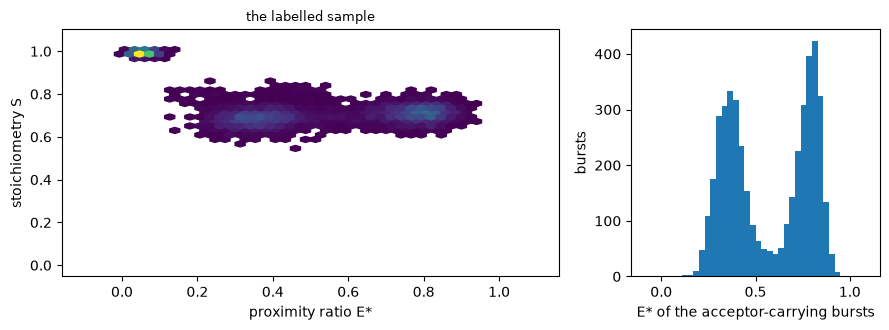

In [6]:
sel, bursts = {}, {}
for s in ('DA', 'D0'):
    sel[s], bursts[s] = P.burst_search(model, tttr[s], S)
    n = len(tttr[s].macro_times)
    print(f'{s}: {len(bursts[s])} bursts kept of {len(stream[s]["bursts"])} molecules, '
          f'{len(sel[s])} burst photons of {n} ({100*len(sel[s])/n:.0f} %)')
rows = P.burst_observables(tttr['DA'], bursts['DA'], model)
fig = P.plot_es(rows, 'the labelled sample')

### What the burst search does to the truth

A burst search keeps the bright crossings, and brightness depends on the distance: a
molecule at short distance sends most of its light to the acceptor, whose quantum yield and
detector are not the donor's. So the population *behind the selected bursts* is not quite
the population in the cuvette -- and it is the former that the decays measure. Both are
plotted later, and the difference is a property of the experiment, not an error of the fit.

In [7]:
p_sel, x_sel, cnt = P.burst_truth(model, stream['DA'], tttr['DA'], bursts['DA'])
print(f"donor-only fraction:  in the cuvette {S['donor_only_fraction']:.3f},  among the selected bursts {x_sel:.3f}")
print(f"mean R/R0:            in the cuvette {float((p_true*rel).sum()):.4f},  among the selected bursts {float((p_sel*rel).sum()):.4f}")
print(f"{int(cnt.sum())} FRET molecules behind the selected bursts")

donor-only fraction:  in the cuvette 0.200,  among the selected bursts 0.188
mean R/R0:            in the cuvette 1.0000,  among the selected bursts 0.9980
4495 FRET molecules behind the selected bursts


## 6. The decays

The micro times of the selected photons, histogrammed. The labelled sample's histograms
hold **both pulses**: the donor decay after the green pulse, and 25 ns later the directly
excited acceptor after the red one. They are fitted as they are, unmasked -- the two pulses
only split the histogram to produce starting values.

  D0 gh_vh:    107873 counts
  D0 gv_vv:    155569 counts
  D0 rh_vh:      7490 counts
  D0 rv_vv:     10178 counts
  DA gh_vh:    161984 counts
  DA gv_vv:    243743 counts
  DA rh_vh:    300190 counts
  DA rv_vv:    381367 counts


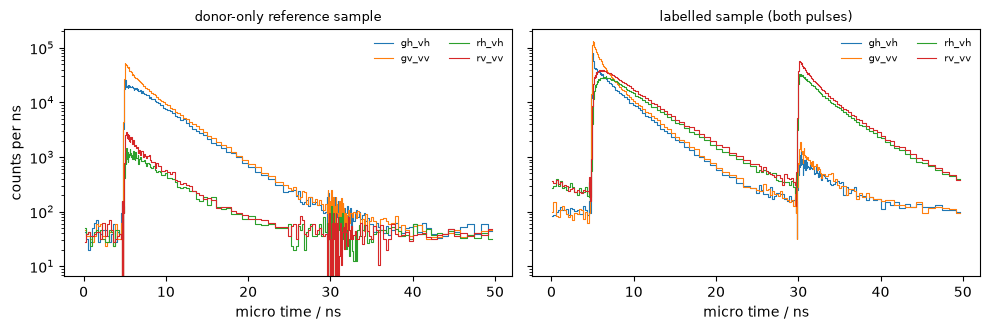

In [8]:
y = P.assemble_data(model,
                    P.burst_decays(model, tttr['D0'], sel['D0'], 'D0'),
                    P.burst_decays(model, tttr['DA'], sel['DA'], 'DA'))
tc = model['Ep']['tc']; wid = model['Ep']['wid']
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for i, samp in enumerate(('D0', 'DA')):
    for k in sorted([k for k in y if k[0] == samp], key=str):
        ax[i].step(tc, np.asarray(y[k]) / wid, where='mid', lw=0.8, label=k[1])
    ax[i].set_yscale('log'); ax[i].set_xlabel('micro time / ns')
    ax[i].legend(fontsize=7, frameon=False, ncol=2)
    ax[i].set_title({'D0': 'donor-only reference sample', 'DA': 'labelled sample (both pulses)'}[samp], fontsize=9)
ax[0].set_ylabel('counts per ns'); fig.tight_layout()
for k in sorted([k for k in y if k[0] != 'A0'], key=str):
    print(f'  {k[0]} {k[1]}: {float(y[k].sum()):>9.0f} counts')

## 7. The posterior

One fit: p(R/R0), the donor-only fraction, the donor lifetime spectrum, the acceptor's
lifetimes, both anisotropies and their rotational times, the g factor, the crosstalks, the
quantum yields, the direct excitation, the response shifts, and a scale, a scatter fraction
and a background per histogram.

For each node of the roughness-weight grid the mode is found by Fisher scoring with
Levenberg-Marquardt damping, and the posterior there is the Gaussian whose precision is the
expected information plus the prior curvature. The nodes are then mixed by their evidences.
The grid is refined around the evidence maximum, which is why more nodes are reported than
were asked for. Expect a few minutes.

In [9]:
t0 = time.time()
graph, post = P.fit(model, y, S, verbose=False)
print(f'fitted in {time.time()-t0:.0f} s\n')
print(f"{'log10 lambda':>13}{'evidence':>14}{'weight':>9}{'D/dof':>9}{'iterations':>12}")
ev0 = max(r['evidence'] for r in P.node_table(post))
for r in P.node_table(post):
    if r['weight'] > 1e-3:
        print(f"{r['log10_lam']:>13.2f}{r['evidence']-ev0:>14.2f}{r['weight']:>9.3f}{r['dpd']:>9.4f}{r['iterations']:>12d}")
print(f"\nthe evidence maximum is at log10 lambda = {post['best_lam']:.2f};"
      f" evidences are shown relative to it")

/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:2863: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet


/Users/tpeulen/mambaforge/envs/arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


fitted in 358 s

 log10 lambda      evidence   weight    D/dof  iterations
        -1.25         -5.11    0.001   1.0638          61
        -1.00         -3.87    0.005   1.0643          31
        -0.75         -3.30    0.008   1.0641          61
        -0.50         -2.07    0.028   1.0647          31
        -0.25         -1.28    0.061   1.0649          31
         0.00         -0.63    0.117   1.0652          59
         0.25         -0.18    0.183   1.0656          24
         0.50          0.00    0.220   1.0661          26
         0.75         -0.13    0.194   1.0667          24
         1.00         -0.61    0.119   1.0674          31
         1.25         -1.51    0.049   1.0684          24
         1.50         -2.88    0.012   1.0697          27
         1.75         -4.78    0.002   1.0716          29

the evidence maximum is at log10 lambda = 0.50; evidences are shown relative to it


## 8. Rule 0: no result without weighted residuals and a fit statistic

Every number below is only worth reading if the model actually fits the counts. Two checks,
both of which could fail:

* **weighted residuals**, (counts - model) / sqrt(model), plotted under every histogram, and
  a **runs test** on their signs -- a small p value means the residuals come in streaks, that
  is, the model has the wrong shape somewhere.
* the **Poisson deviance per degree of freedom**, with its dof printed. Its reference is not
  1: for counts of this size the deviance of a *correct* model is close to the number of
  bins, while the dof subtracts the full parameter dimension even though the penalised
  spline uses far fewer. So the reference is measured -- Poisson draws at the fitted means --
  and the fit is good when D/dof falls inside that scatter.

D/dof = 1.0661   dof = 1694
reference for a correct model at these means: 1.0830 +- 0.0357
-> -0.5 standard deviations

histogram         D/dof   runs p
D0 gh_vh          1.133    0.485
D0 gv_vv          1.054    0.222
D0 rh_vh          0.966    0.775
D0 rv_vv          1.063    0.163
DA gh_vh          1.060    0.657
DA gv_vv          1.144    0.232
DA rh_vh          1.021    0.284
DA rv_vv          1.087    0.894


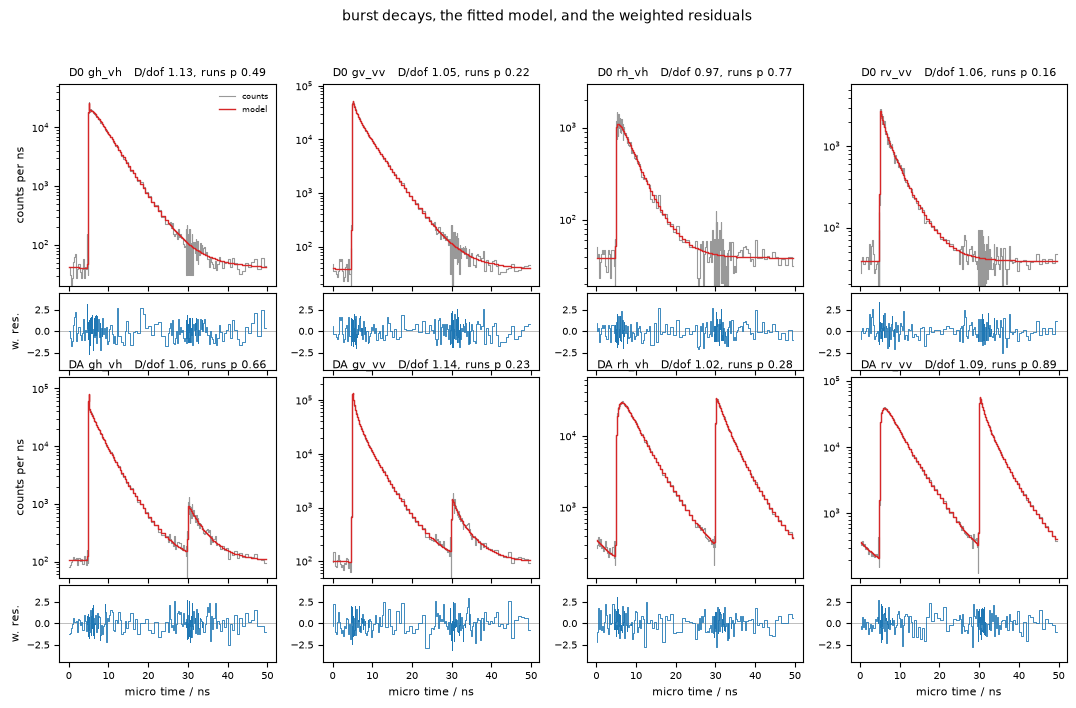

In [10]:
ref, ref_sd = P.poisson_reference(post, n_draw=200, seed=1)
dpd = post['dev'] / post['dof']
print(f"D/dof = {dpd:.4f}   dof = {post['dof']}")
print(f"reference for a correct model at these means: {ref:.4f} +- {ref_sd:.4f}")
print(f"-> {(dpd - ref)/ref_sd:+.1f} standard deviations\n")
print(f"{'histogram':<14}{'D/dof':>9}{'runs p':>9}")
for k in sorted(post['rows'], key=str):
    r = post['rows'][k]
    print(f"{k[0]+' '+k[1]:<14}{r['dpd']:>9.3f}{r['runs_p']:>9.3f}")
fig = P.plot_decays(model, y, post, 'burst decays, the fitted model, and the weighted residuals')

## 9. The distance distribution

The band is the delta method at each grid point, mixed over the penalty nodes and clipped at
zero.

The **grey regions** are where the measurement cannot speak. The transfer efficiency is
1/(1+(R/R0)^6): below about 0.7 R/R0 it is within a percent of one and above about 1.5 it is
within a percent of zero, so in both a large change of distance moves the decay by nothing.
A curve drawn through the grey is the prior, not the data. This is chisurf's convention for
the usable window.

The summaries under the figure are first order in the posterior -- the delta method at the mode of each penalty node, mixed over the nodes -- so their intervals are Gaussian and can reach past a boundary a quantity cannot cross. A negative lower edge on the tail mass means the data do not exclude zero, not that negative mass is possible.

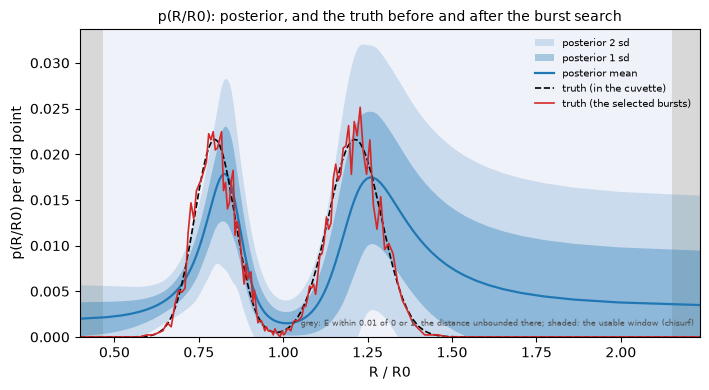

In [11]:
fig = P.plot_pR(model, post, p_true=p_true, p_selected=p_sel, dE=0.01,
                title='p(R/R0): posterior, and the truth before and after the burst search')

In [12]:
truth = dict(x_d0=x_sel,
             mean=float((p_sel * rel).sum()),
             sd=float(np.sqrt((p_sel * (rel - (p_sel*rel).sum())**2).sum())),
             tail=float(p_sel[rel > 1.3].sum()),
             r0_d=S['r0_donor'], r0_a=S['r0_acceptor'], g=model['L'].S.G_TRUE)
print(f"{'quantity':<10}{'truth':>9}{'posterior':>11}{'sd':>9}{'95 % interval':>22}   covers")
for r in P.summary_table(model, post, truth):
    print(f"{r['quantity']:<10}{r['truth']:>9.4f}{r['mean']:>11.4f}{r['sd']:>9.4f}"
          f"   [{r['lo']:.4f}, {r['hi']:.4f}]{'':>3}{'yes' if r['inside'] else 'NO'}")
print(f"\nwhole notebook: {time.time()-t_all:.0f} s")

quantity      truth  posterior       sd         95 % interval   covers


x_d0         0.1885     0.1193   0.0715   [-0.0239, 0.2566]   yes
mean         0.9980     1.0548   0.0566   [0.9474, 1.1700]   yes
sd           0.2044     0.2796   0.0574   [0.1703, 0.3952]   yes
tail         0.0449     0.1970   0.1177   [-0.0423, 0.4196]   yes
r0_d         0.3600     0.3577   0.0117   [0.3348, 0.3807]   yes
r0_a         0.1800     0.1691   0.0088   [0.1519, 0.1863]   yes
g            1.1500     1.1548   0.0059   [1.1434, 1.1663]   yes

whole notebook: 364 s


## 10. Does the interval mean what it says?

One posterior covering its truth proves nothing, and one missing proves nothing either.
Only the spread over repeated experiments does. So the whole pipeline -- new molecules, new
photons, a new burst search, a new fit -- runs a few more times, and the **pull** is plotted:
posterior mean minus truth, divided by the posterior standard deviation. Honest intervals
give pulls scattered about zero with a spread of one.

The repeats use fewer bursts and a coarser penalty grid so that they finish in a couple of
minutes; set `REPEAT_SEEDS = ()` in cell 1 to skip them.

3 repeats in 252 s

  seed    D/dof   reference
    11    1.076    1.100 +- 0.037
    12    1.045    1.091 +- 0.035
    13    1.101    1.093 +- 0.033

x_d0     mean pull -0.49   spread 0.31
mean     mean pull +0.55   spread 0.34
sd       mean pull +0.89   spread 0.14
tail     mean pull +0.76   spread 0.17
r0_d     mean pull -0.57   spread 0.21
r0_a     mean pull -1.23   spread 0.86
g        mean pull +0.68   spread 0.83


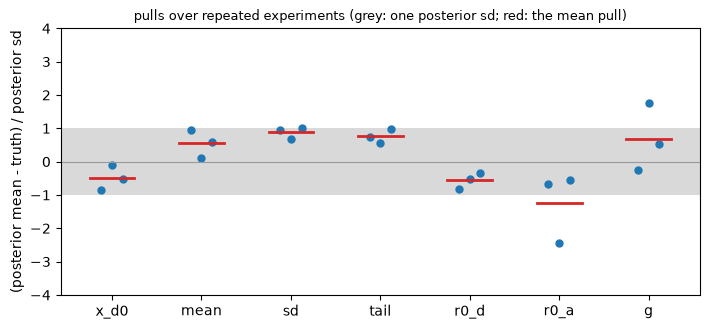

In [13]:
if REPEAT_SEEDS:
    S_rep = dict(S, n_bursts=2500, n_bursts_donor=1200, lam_nodes=(0.5, -0.5))
    model['L'].LAM_REFINE_STEP = 0.0          # no refinement around the evidence maximum
    t0 = time.time()
    pulls, stats = P.repeat_experiment(model, S_rep, tab, p_true, REPEAT_SEEDS)
    print(f'{len(REPEAT_SEEDS)} repeats in {time.time()-t0:.0f} s\n')
    print(f"{'seed':>6}{'D/dof':>9}{'reference':>12}")
    for st_ in stats:
        print(f"{st_['seed']:>6}{st_['dpd']:>9.3f}{st_['ref']:>9.3f} +- {st_['ref_sd']:.3f}")
    print()
    for n, v in pulls.items():
        z = np.array([(m - t) / s for t, m, s in v])
        print(f'{n:<8} mean pull {z.mean():+.2f}   spread {z.std(ddof=0):.2f}')
    fig = P.plot_pulls(pulls)

What this run actually shows, at these settings and over three repeats -- which is too
few to separate a bias from its scatter, and is quoted as what it is:

| quantity | mean pull |
|---|---|
| width of p(R/R0) | +0.9 |
| far-tail mass above 1.3 R/R0 | +0.8 |
| donor-only fraction | -0.5 |
| acceptor anisotropy | -1.2 |
| mean of p(R/R0), g factor, donor anisotropy | within half a standard deviation |

The first three move together and are one effect: information the nuisances do not pin down
is absorbed by p(R/R0) as extra width, and the width is paid for out of the donor-only
fraction. That trade is a measured property of this posterior, not of this notebook, and the
study behind it -- hundreds of truths, ranks rather than pulls -- lives in the ucfret
investigation `okf/writeup-laplace-posterior.md`, which also states where it stops working:
two populations separate reliably when their centres are 0.30 R/R0 apart, sometimes at 0.20,
never at 0.15, and never at all above about 1.4 R/R0.

Two things worth trying from cell 1, because both change the picture:

* the scatter fraction and the rotational correlation time have priors centred on the
  prototype's own values (0.02 and 1.2 ns). Simulate away from those centres and the
  anisotropies bias, because the prior then pulls the early part of the decay, which is
  exactly where the anisotropy lives. At 0.004 scatter and 1.0 ns the donor anisotropy came
  out 1.5 standard deviations low in every one of five seeds.
* the anisotropy amplitudes and the g factor are partly degenerate: all act on the ratio of
  the two polarisation channels, and their errors anticorrelate.

An example is not a calibration, and three repeats are not either. What they are good for is
showing that the question can be asked here at all, and roughly where the answer sits.

## What to try next

* **Move the populations together** in cell 1 until the posterior stops resolving them. Two
  populations of width 0.06 R/R0 separate reliably when their centres are 0.30 apart, sometimes
  at 0.20, never at 0.15 -- and never at all above about 1.4 R/R0, where the decay barely
  changes with distance.
* **Push a population into the grey.** The posterior will put weight there, and the band will
  be as wide as the region is uninformative. That is the honest answer, and it is why the
  region is drawn.
* **Cut `photons_per_burst` or `n_bursts`.** Watch the band widen and the two populations
  merge; watch D/dof stay near its reference, because a wrong answer with a good fit is
  exactly what a distance distribution can look like.
* **Raise `background_cps` or `scatter_fraction`.** Both are free parameters of the fit, so
  the cost appears as width in the posterior, not as misfit.
* **Turn off PIE** by setting `red_green_ratio` to a small number. The donor-only fraction is
  what loses its footing first: without the red pulse, a molecule with a dead acceptor and one
  with a very long distance look alike.

### Attribution

Written for the bff examples, 2026-09-08. The forward model, the Laplace-on-a-factor-graph
posterior and the evidence mixture over the penalty weight are the ucfret prototype
`s88_laplace_posterior` (investigation `pinn_pR_anisotropy`); the photon stream, the burst
search and this notebook are the example around it.